## Prepare the notebook

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the data
df = pd.read_csv("D:/Programming/Data_science/Codveda-Internship/Level 1/Task 2/processed_real_estate.csv")

df

,name,sqm,year_built,Price(EGP),Price/Sqm,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,...,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier,Is log(price) outlier,Is FloorNumber outlier
0,Alamain (Latin District),92.86,2025,6594000,71010.1228,1,1,0,0,1,...,0,0,0,4.531093,15.701671,11.170578,False,False,False,False
1,Beachfront Tower - B1,398.00,2025,66104000,166090.4523,0,0,0,0,1,...,0,0,0,5.986452,18.006740,12.020288,False,False,True,False
2,PODIA,93.00,2025,12824000,137892.4731,0,1,1,0,1,...,1,0,0,4.532599,16.366829,11.834229,False,False,False,True
3,Mazarine Apartment,252.00,2025,12857000,51019.8413,1,1,0,0,0,...,0,0,0,5.529429,16.369399,10.839970,False,False,False,False
4,Alamain (Latin District),209.42,2025,8721000,41643.5870,1,1,0,0,1,...,0,0,0,5.344342,15.981244,10.636903,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,Zahya,410.00,2024,11028000,26897.5610,1,1,0,1,0,...,0,0,0,6.016157,16.215948,10.199791,False,False,False,False
876,Zahya,410.00,2024,10542000,25712.1951,1,1,0,1,0,...,0,0,0,6.016157,16.170878,10.154721,False,False,False,False
877,Zahya,504.00,2024,11890000,23591.2698,1,1,0,1,0,...,0,0,0,6.222576,16.291208,10.068632,False,False,False,False
878,Zahya,345.00,2024,10209000,29591.3043,1,1,0,1,0,...,0,0,0,5.843544,16.138780,10.295236,False,False,False,False


## The chart of years

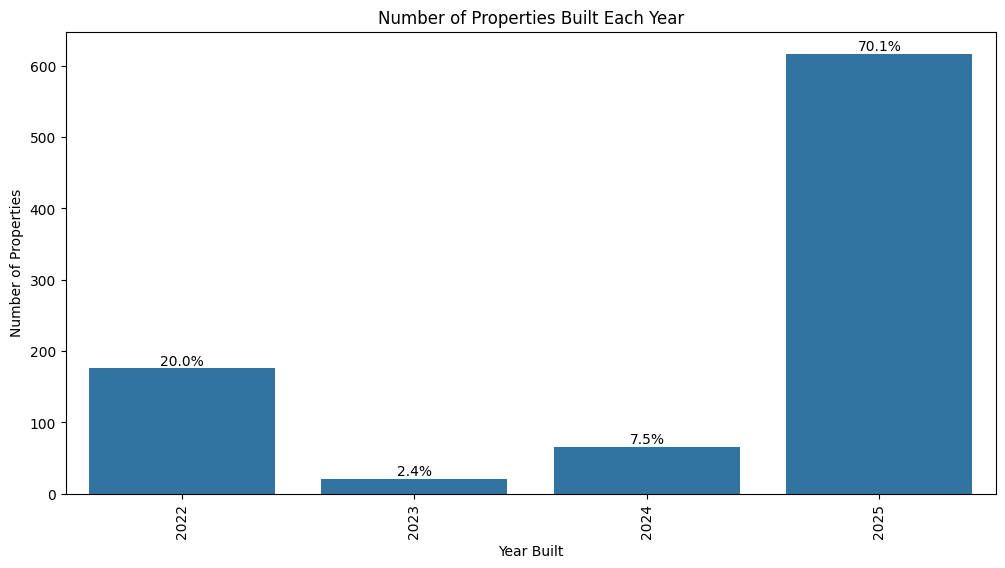

In [3]:
df["year_built"] = df["year_built"].astype(str) # convert the type of it to string for better visualization
plt.figure(figsize=(12, 6)) # set the figure size
order = df["year_built"].sort_values().unique() # get the unique years in sorted order
ax = sns.countplot(data=df, x="year_built", order=order) # create the count plot
plt.xticks(rotation=90) # rotate the x labels for better readability
# Add title and labels
plt.title("Number of Properties Built Each Year")
plt.xlabel("Year Built")
plt.ylabel("Number of Properties")
# show the percentages on top of the bars
total = df.shape[0]
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', labels=[f'{(v.get_height()/total)*100:.1f}%' for v in container]) # show the percentages

- We have imbalanced data in terms of years built.
- Most of the collected properties were built in 2025.
- Exclude 2023 from the time series data due to small data amount

In [4]:
year_2023 = df[df["year_built"] == "2023"]
df.drop(year_2023.index, inplace=True)
df[:10]

,name,sqm,year_built,Price(EGP),Price/Sqm,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,...,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier,Is log(price) outlier,Is FloorNumber outlier
0,Alamain (Latin District),92.86,2025,6594000,71010.1228,1,1,0,0,1,...,0,0,0,4.531093,15.701671,11.170578,False,False,False,False
1,Beachfront Tower - B1,398.00,2025,66104000,166090.4523,0,0,0,0,1,...,0,0,0,5.986452,18.006740,12.020288,False,False,True,False
2,PODIA,93.00,2025,12824000,137892.4731,0,1,1,0,1,...,1,0,0,4.532599,16.366829,11.834229,False,False,False,True
3,Mazarine Apartment,252.00,2025,12857000,51019.8413,1,1,0,0,0,...,0,0,0,5.529429,16.369399,10.839970,False,False,False,False
4,Alamain (Latin District),209.42,2025,8721000,41643.5870,1,1,0,0,1,...,0,0,0,5.344342,15.981244,10.636903,False,False,False,False
5,Latin City,139.00,2025,6688000,48115.1079,0,1,0,0,1,...,0,0,0,4.934474,15.715825,10.781352,False,False,False,False
6,Downtown commercial,272.00,2025,32696000,120205.8824,1,1,0,0,1,...,0,0,1,5.605802,17.302763,11.696961,False,False,False,False
7,Beachfront Tower - B1,221.00,2025,28507000,128990.9502,0,0,0,0,1,...,0,0,0,5.398163,17.165660,11.767498,False,False,False,True
8,Downtown commercial,319.00,2025,36428000,114194.3574,1,1,0,0,1,...,0,0,1,5.765191,17.410848,11.645657,False,False,True,False
9,Downtown Extension,173.00,2022,8368000,48369.9422,1,1,0,1,1,...,0,0,0,5.153292,15.939925,10.786634,False,False,False,False


In [5]:
df[-10:]

,name,sqm,year_built,Price(EGP),Price/Sqm,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,...,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier,Is log(price) outlier,Is FloorNumber outlier
867,Zahya,504.0,2024,12393000,24589.2857,1,1,0,1,0,...,0,0,0,6.222576,16.332642,10.110066,False,False,False,False
868,Zahya,410.0,2024,10538000,25702.4390,1,1,0,1,0,...,0,0,0,6.016157,16.170498,10.154341,False,False,False,False
869,Zahya,609.8,2024,17616000,28888.1601,1,1,0,1,0,...,0,1,0,6.413131,16.684318,10.271187,False,True,False,False
870,Zahya,498.0,2024,12192000,24481.9277,1,1,0,1,0,...,0,0,0,6.210600,16.316291,10.105690,False,False,False,False
873,Zahya,892.0,2024,22026000,24692.8251,1,1,0,1,0,...,0,1,0,6.793466,16.907734,10.114268,False,True,False,False
874,Zahya,325.0,2024,11375000,35000.0000,1,1,0,1,0,...,0,0,0,5.783825,16.246929,10.463103,False,False,False,False
875,Zahya,410.0,2024,11028000,26897.5610,1,1,0,1,0,...,0,0,0,6.016157,16.215948,10.199791,False,False,False,False
876,Zahya,410.0,2024,10542000,25712.1951,1,1,0,1,0,...,0,0,0,6.016157,16.170878,10.154721,False,False,False,False
877,Zahya,504.0,2024,11890000,23591.2698,1,1,0,1,0,...,0,0,0,6.222576,16.291208,10.068632,False,False,False,False
878,Zahya,345.0,2024,10209000,29591.3043,1,1,0,1,0,...,0,0,0,5.843544,16.138780,10.295236,False,False,False,False


## Model selection

### ADF test to test stationarity

In [ ]:
### Pick y or the time series data
price_data = df["Price(EGP)"]

print(f"\nUsing individual property records: {len(y)} observations")
print("First 5 rows:", y.head())
print("Last 5 rows:", y.tail())


Using individual property records: 859 observations
First 5 rows: 0     6594000
1    66104000
2    12824000
3    12857000
4     8721000
Name: Price(EGP), dtype: int64
Last 5 rows: 874    11375000
875    11028000
876    10542000
877    11890000
878    10209000
Name: Price(EGP), dtype: int64


In [38]:
## See ACF, PACF charts 
def ACF_PACF_Charts(time_series, max_lags = 20, acf_title = None, pacf_title = None):
    """This function plot the ACF, and PACF charts

    Args:
        time_series (array_like): the time series data
        max_lags (int, 20): Max number of lags. Default to 20
        acf_title: the title of the ACF chart. Default to None
        pacf_title: the title of tbe PACF chart. Default to None
    """
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot the ACF
    plot_acf(time_series, ax=ax1, lags=max_lags) # 'lags' sets the maximum number of lags to display
    if acf_title:
        ax1.set_title(acf_title)
    else:
        ax1.set_title("Autocorrelation Function (ACF)")

    # Plot the PACF
    plot_pacf(x=time_series, ax=ax2, lags=max_lags, method='ywm') # 'method' is required for plot_pacf
    if pacf_title:
        ax2.set_title(pacf_title)
    else:
        ax2.set_title("Partial Autocorrelation Function (PACF)")
    

    plt.tight_layout()
    plt.show()

### Try the differences of Price(EGP)

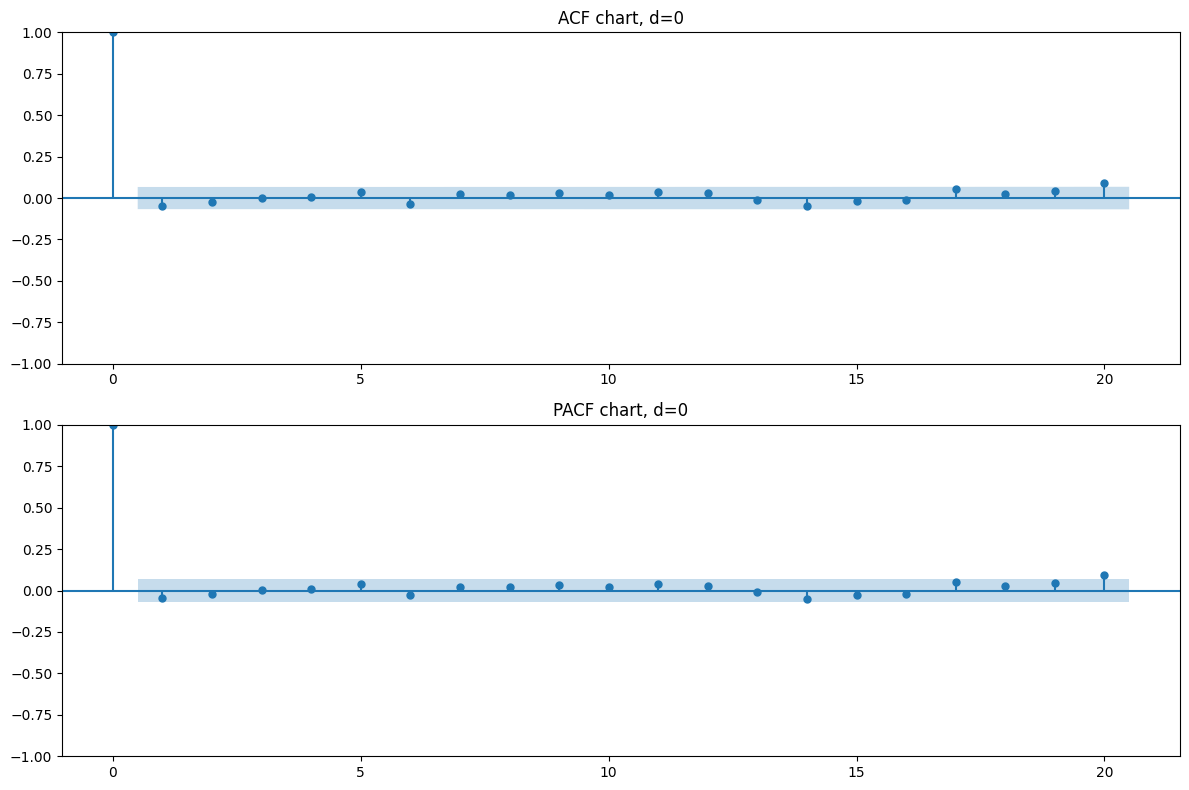

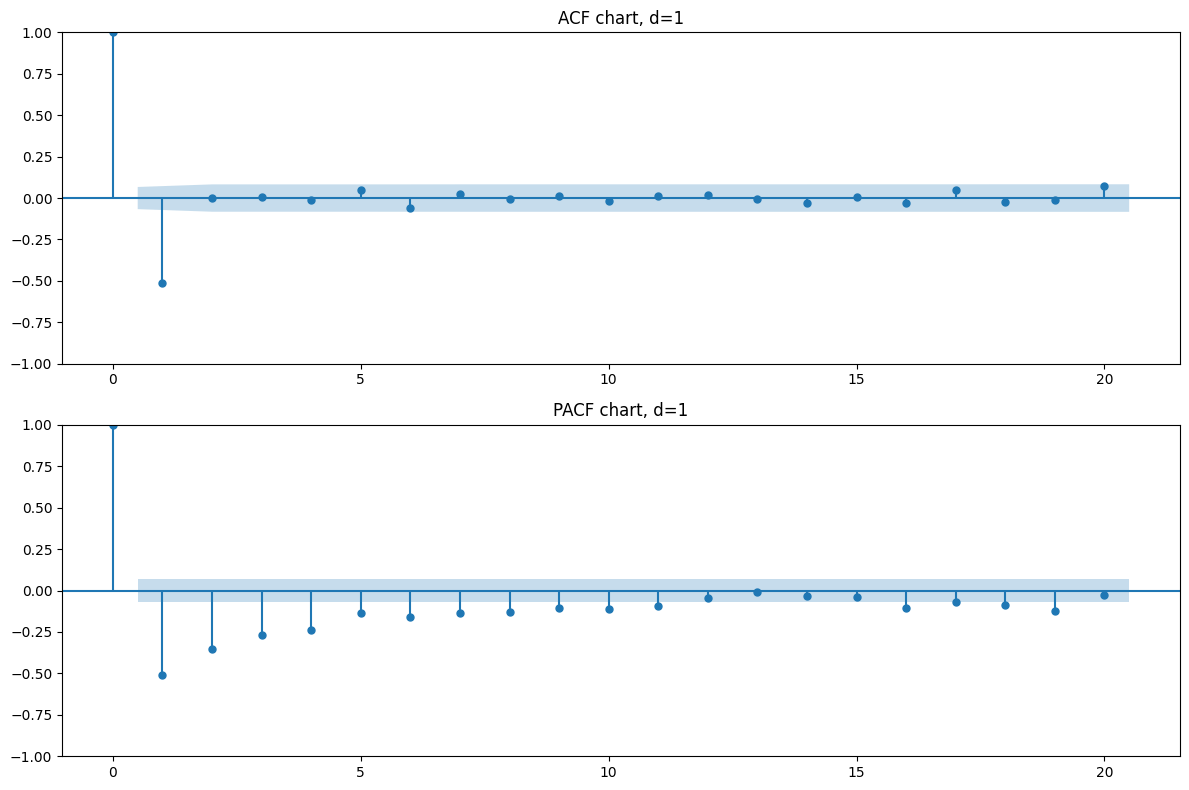

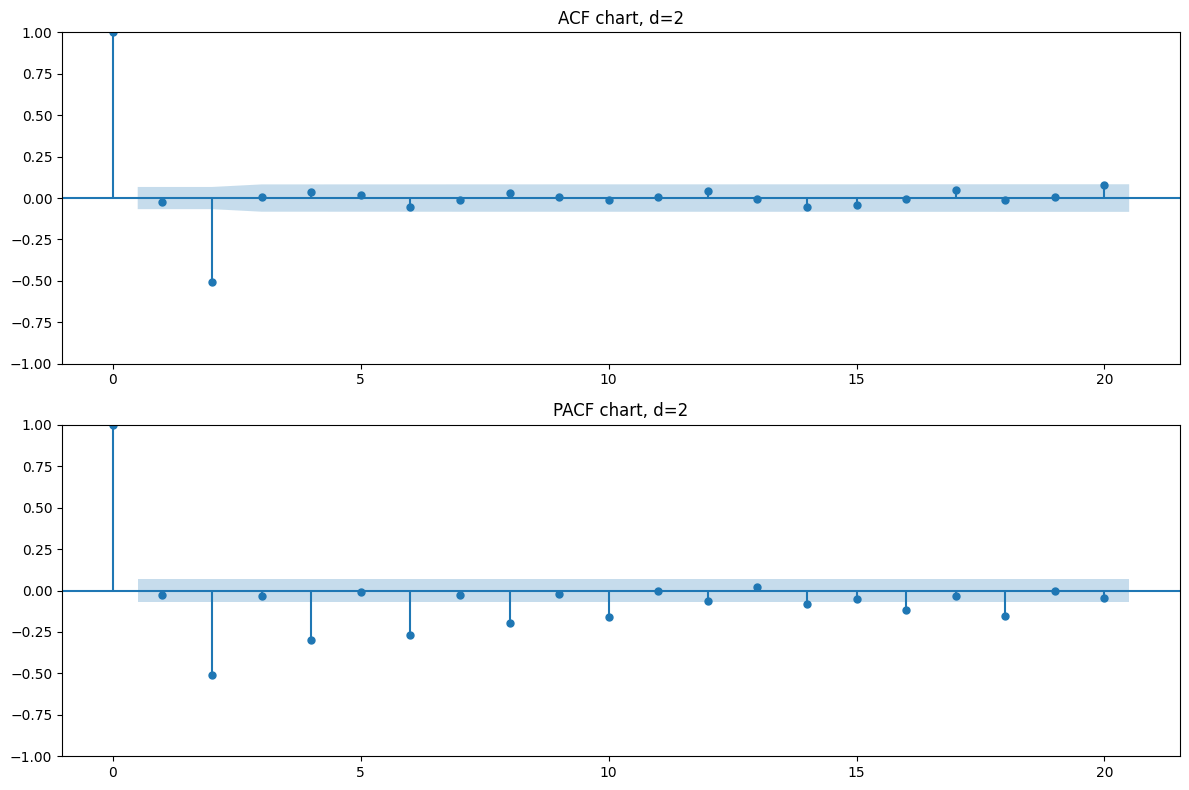

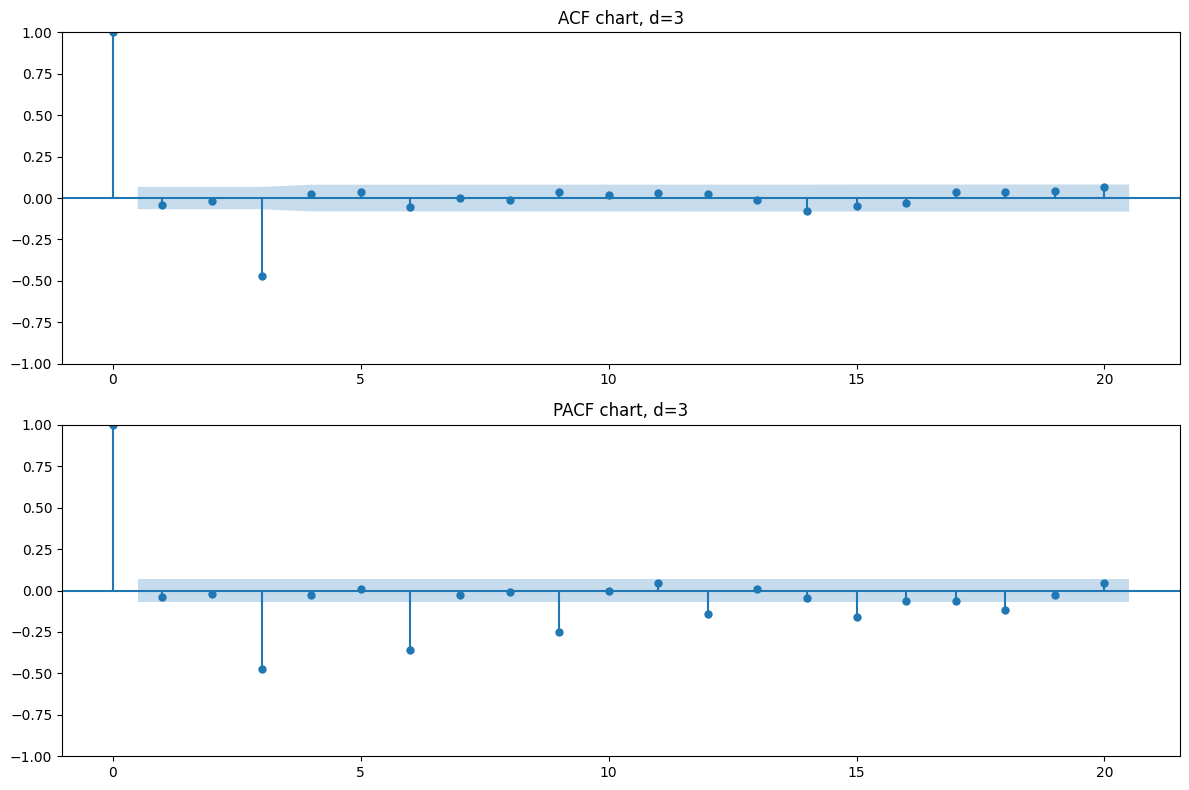

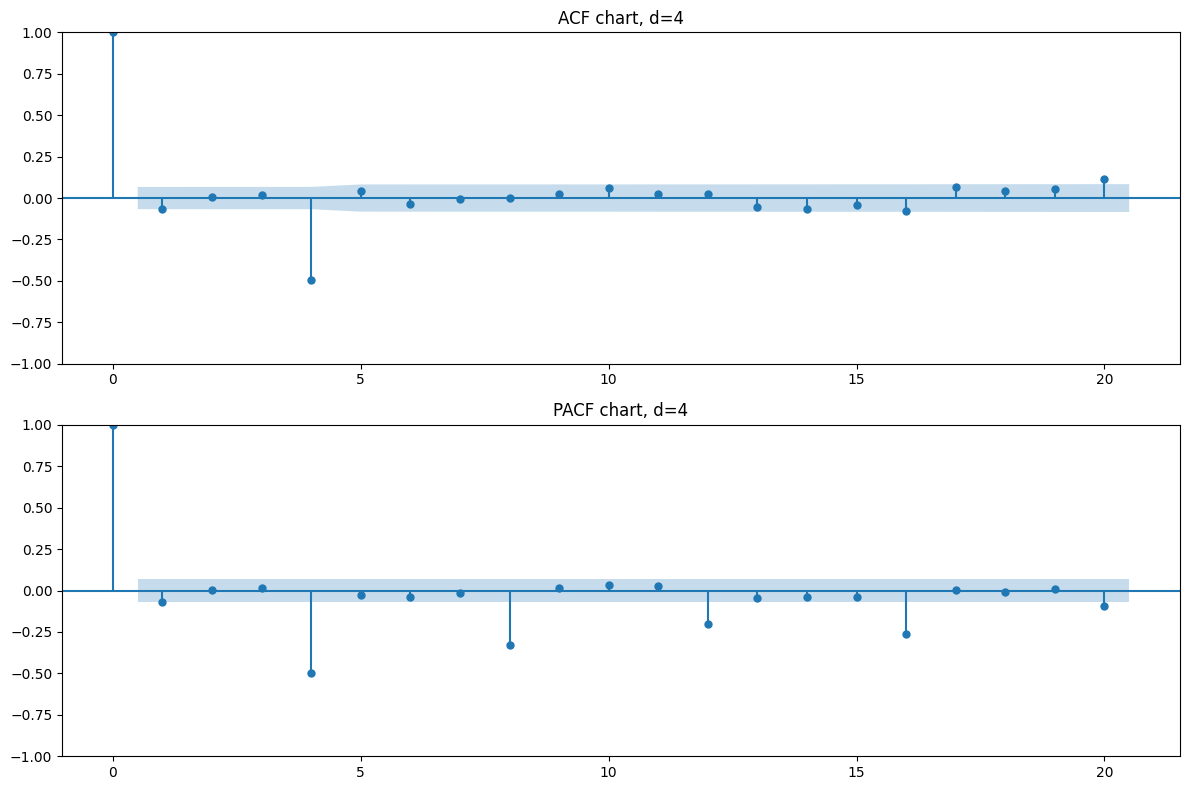

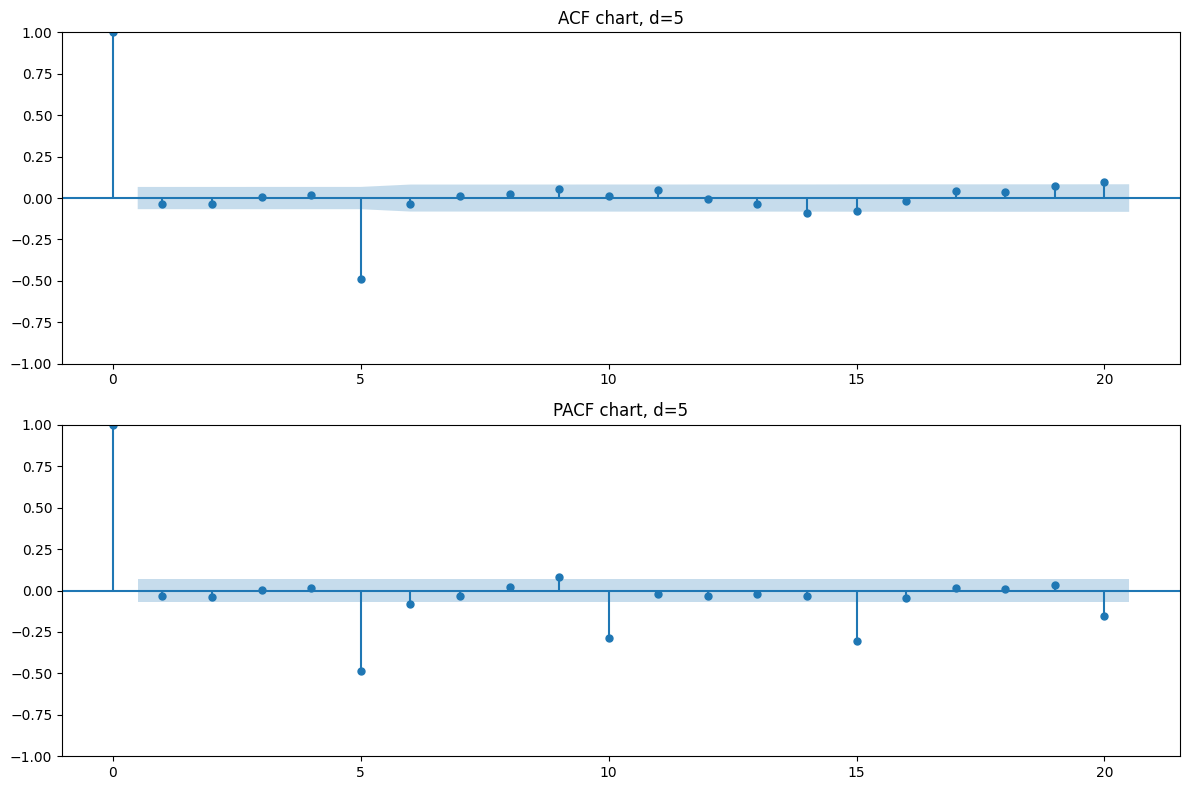

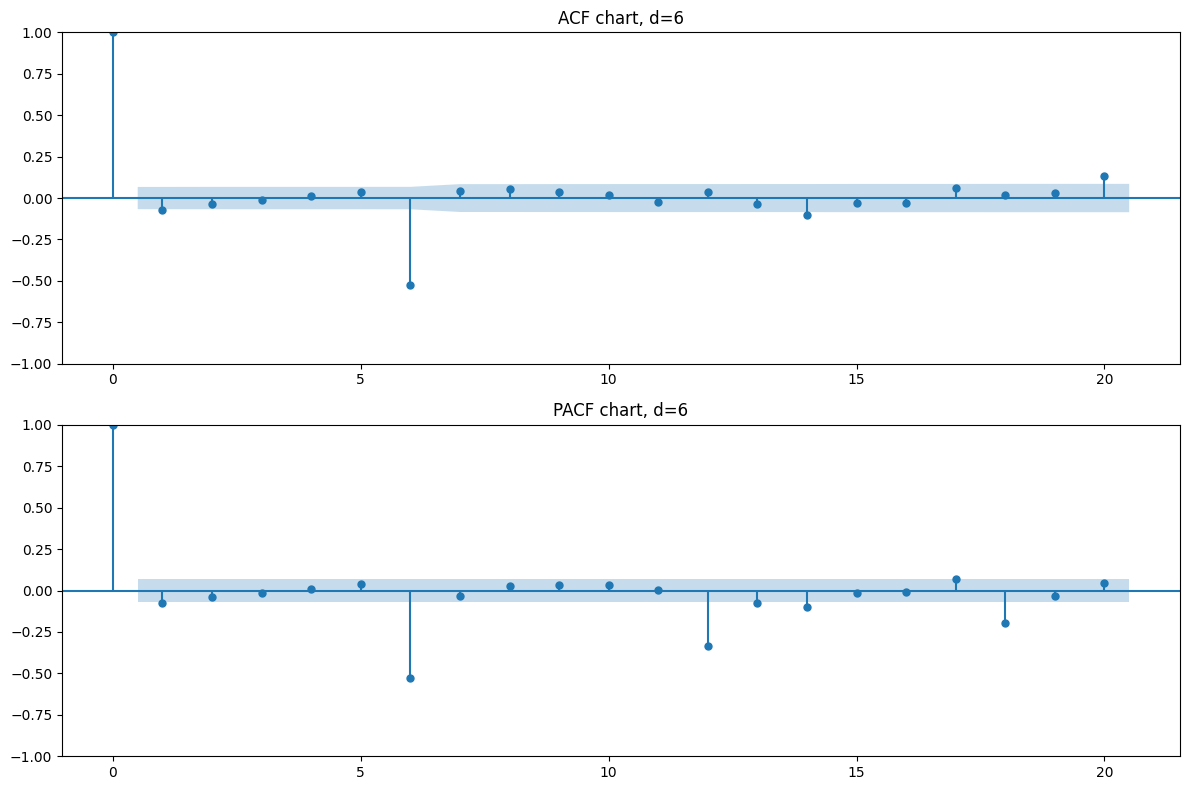

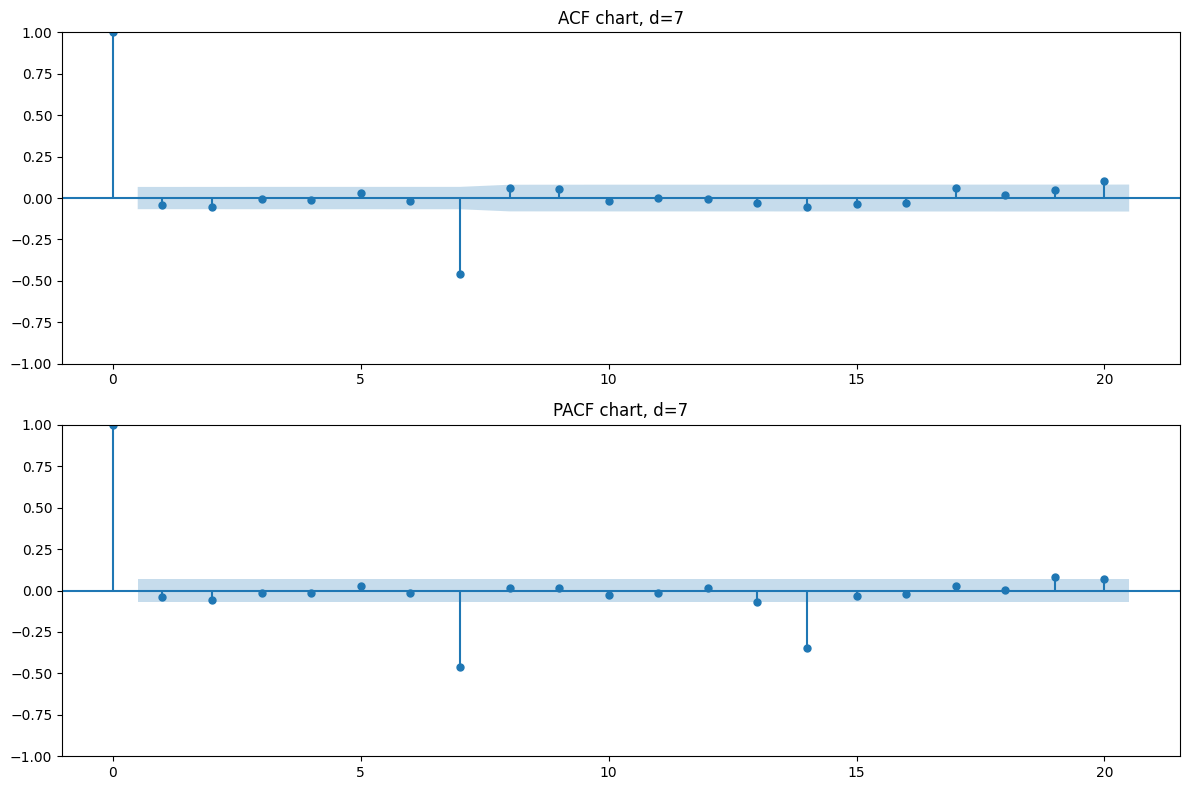

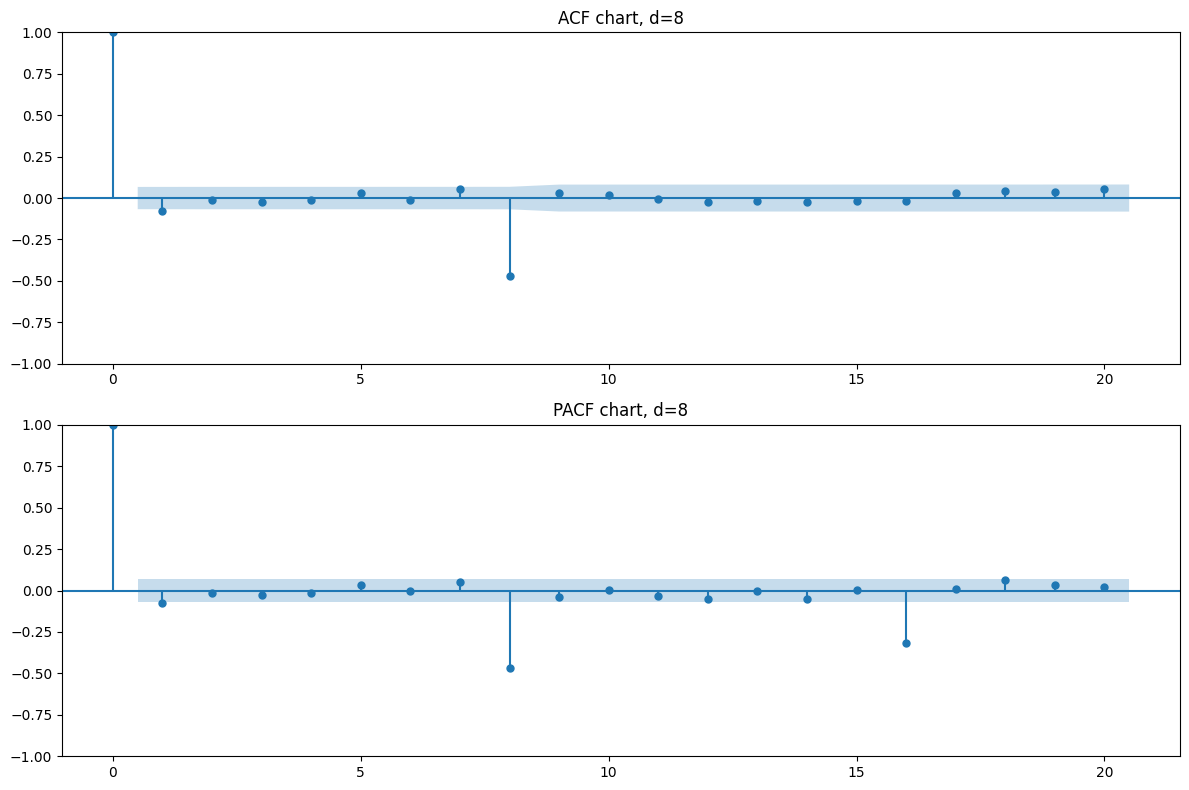

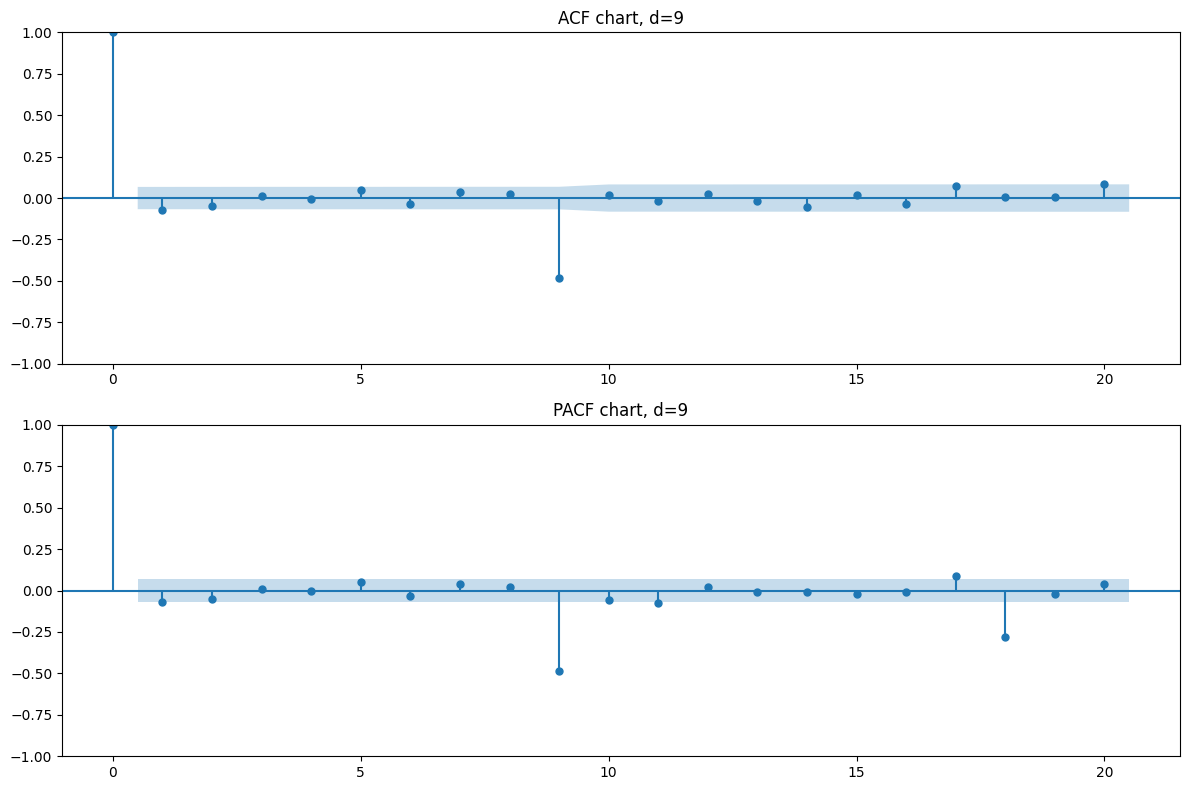

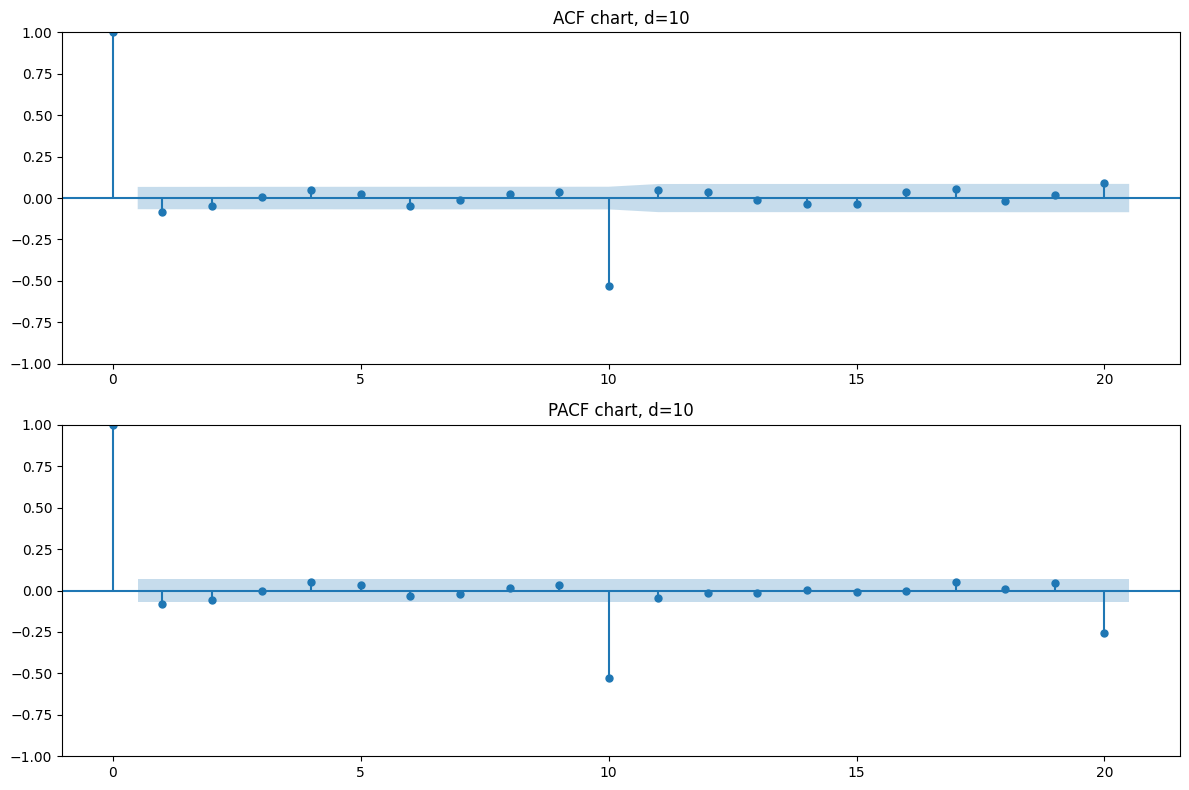

{'adf_test. d=0': (np.float64(-30.677547670503586),
  0.0,
  0,
  858,
  {'1%': np.float64(-3.4379944895149097),
   '5%': np.float64(-2.864914462846141),
   '10%': np.float64(-2.5685668227188505)},
  np.float64(29452.315543631335)),
 'adf_test. d=1': (np.float64(-12.914368694848891),
  np.float64(3.994822050123211e-24),
  18,
  839,
  {'1%': np.float64(-3.438168140637663),
   '5%': np.float64(-2.864991017121922),
   '10%': np.float64(-2.5686076019468094)},
  np.float64(29464.17623404063)),
 'adf_test. d=2': (np.float64(-11.936901886551437),
  np.float64(4.639594621977087e-22),
  19,
  837,
  {'1%': np.float64(-3.4381868797392277),
   '5%': np.float64(-2.864999278011895),
   '10%': np.float64(-2.568612002429454)},
  np.float64(29463.07057450128)),
 'adf_test. d=3': (np.float64(-10.764990800809603),
  np.float64(2.465622551755272e-19),
  20,
  835,
  {'1%': np.float64(-3.4382057088878644),
   '5%': np.float64(-2.865007578546518),
   '10%': np.float64(-2.5686164240381513)},
  np.float64(2

In [ ]:
def d_acf_pacf_charts(time_series, max_d = 3):
    """Return the ACF, and PACF charts of every d value

    Args:
        time_series (array_like): the time series data
        max_d (int, optional): The max value of d(Differences). Defaults to 3.
    Return: 
        adfuller_dict: The adf test of every value of d.
    """
    adfuller_dict = {}
    for d in range(0,max_d+1):
        if d == 0:
            y_d = time_series # y(d = 0)
        else:
            y_d = time_series.diff(d).dropna() # y(-d)

        adfuller_dict[f"adf_test. d={d}"] = adfuller(y_d)
        ACF_PACF_Charts(y_d, acf_title=f"ACF chart, d={d}", pacf_title=f"PACF chart, d={d}")
    return adfuller_dict
d_acf_pacf_charts(price_data,5)

Price(EGP) isn't suitable for forecasting

### Try differences of Sqm

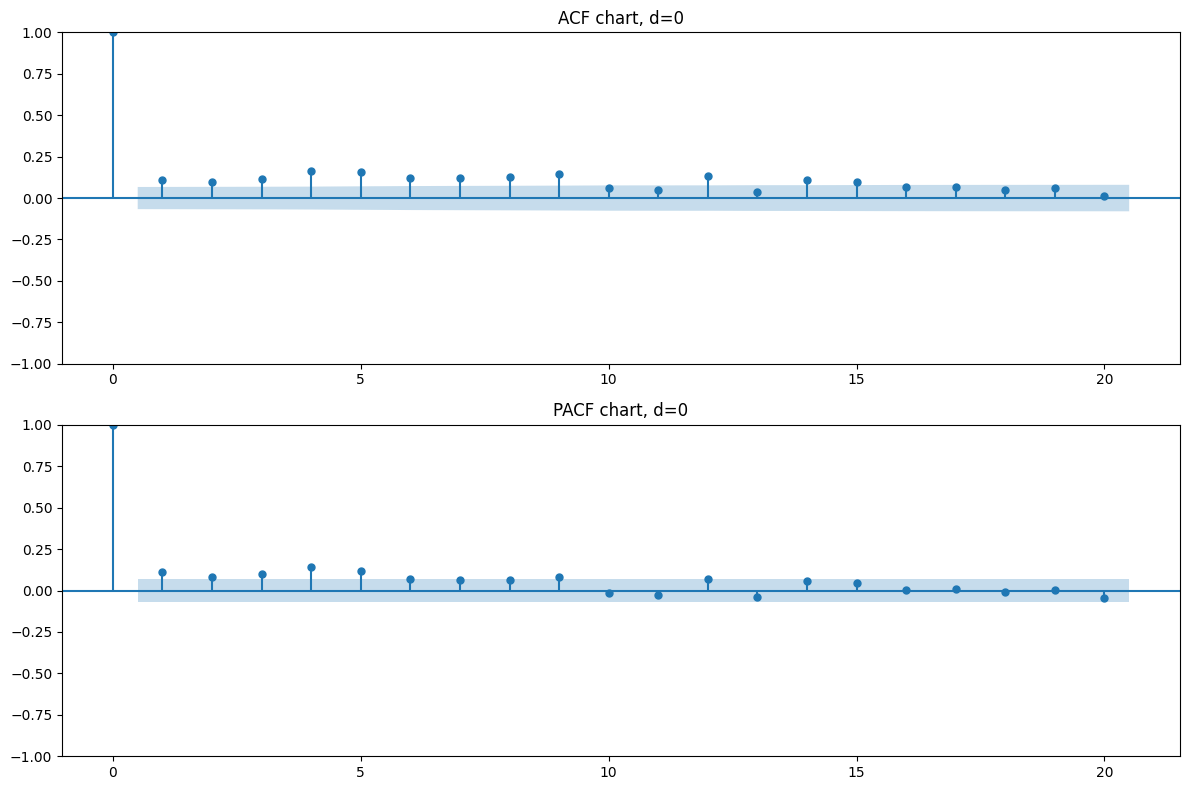

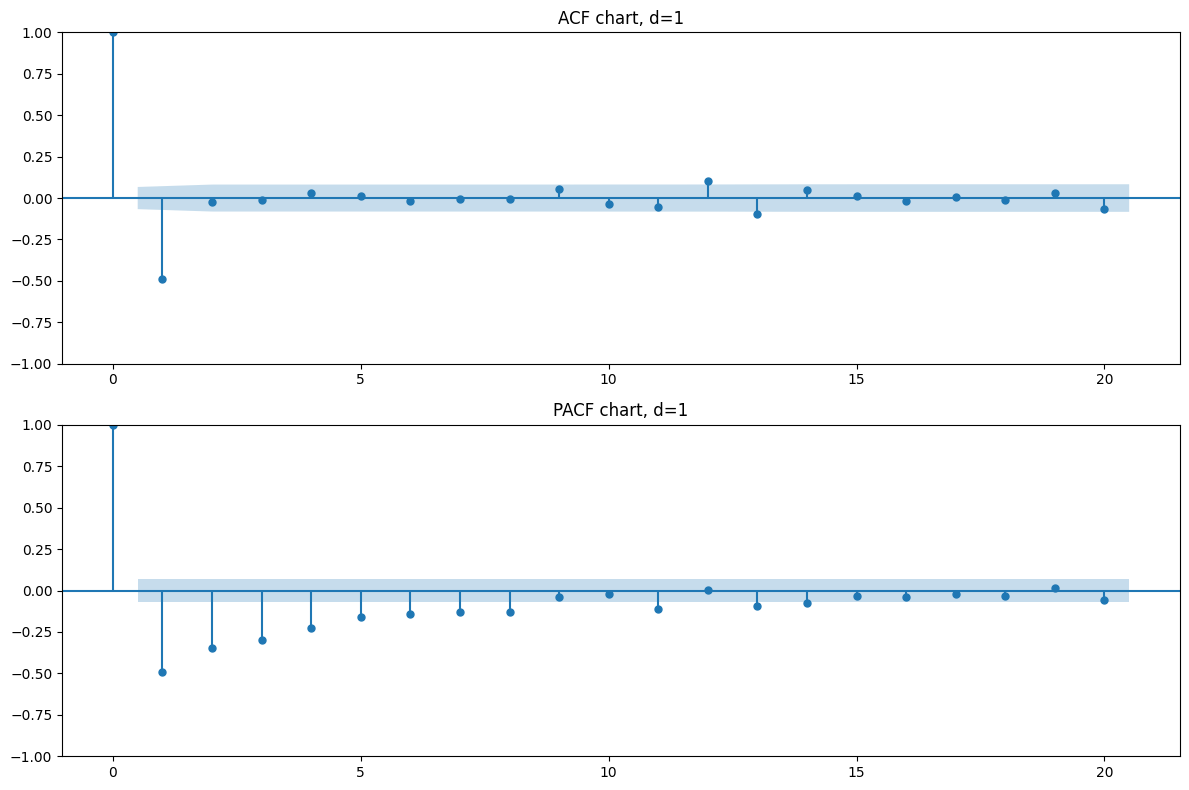

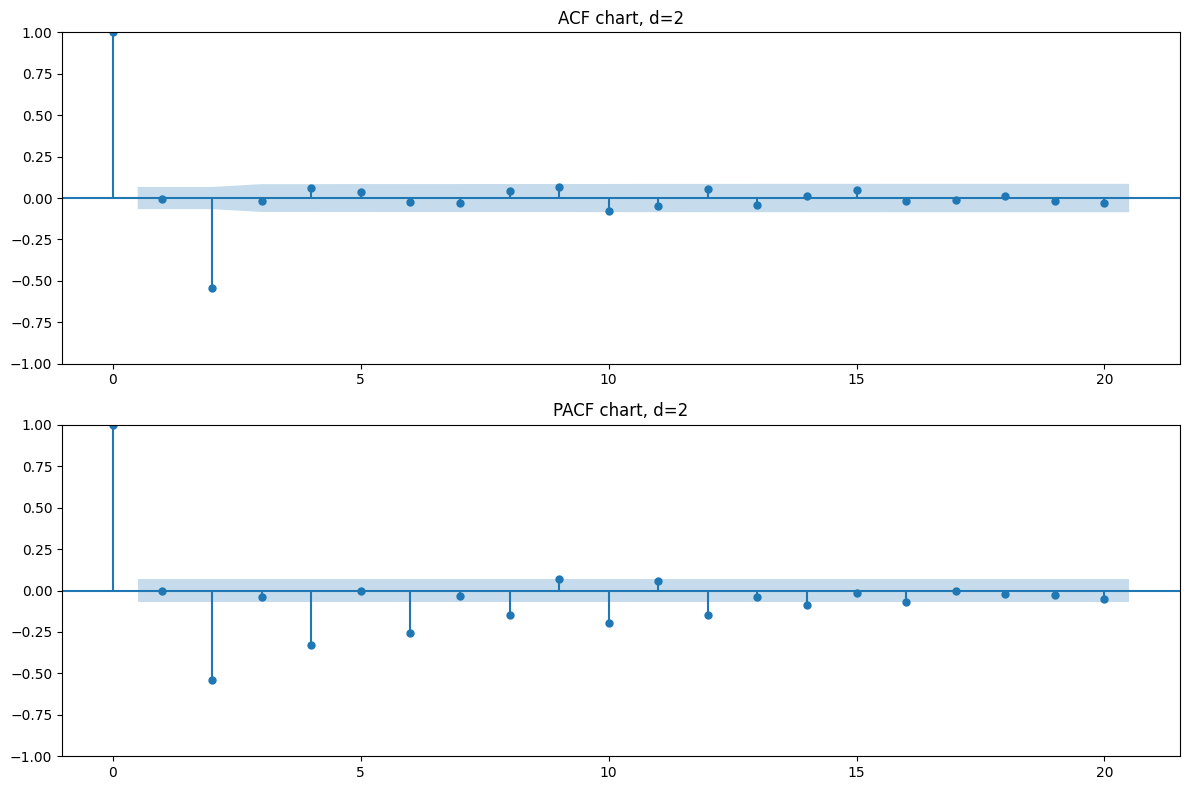

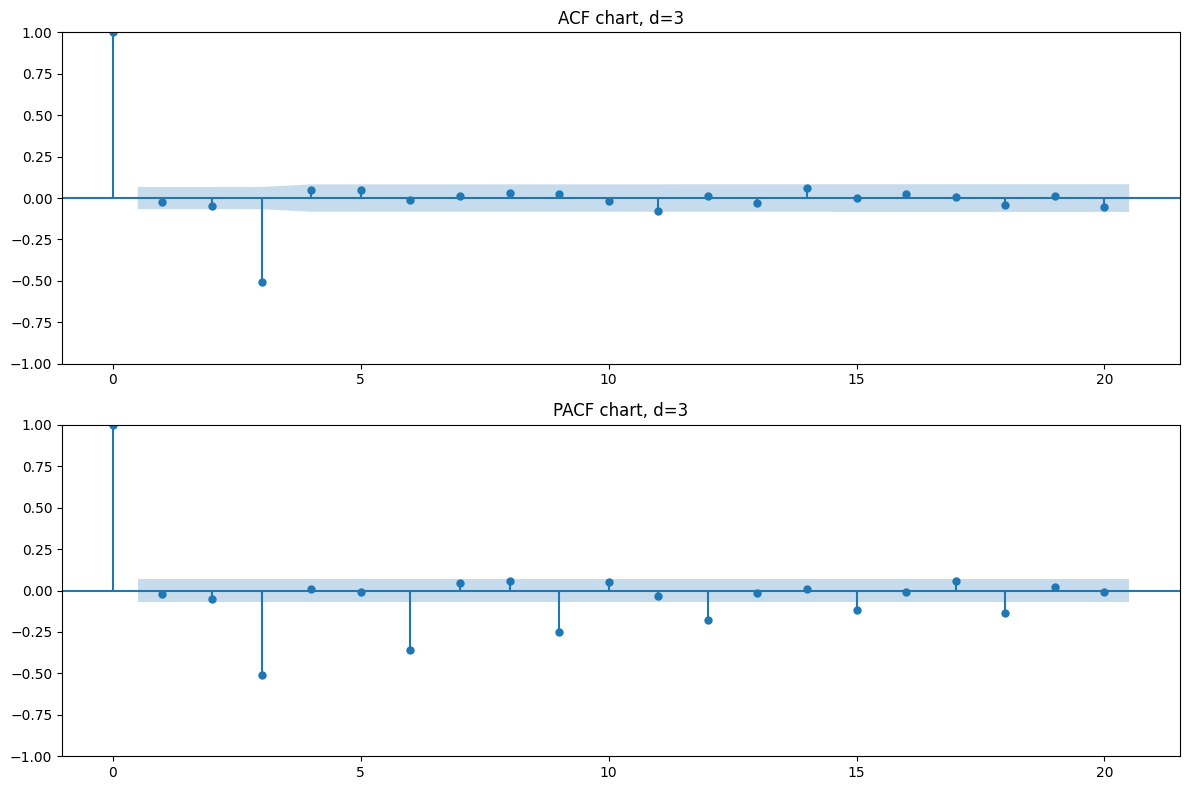

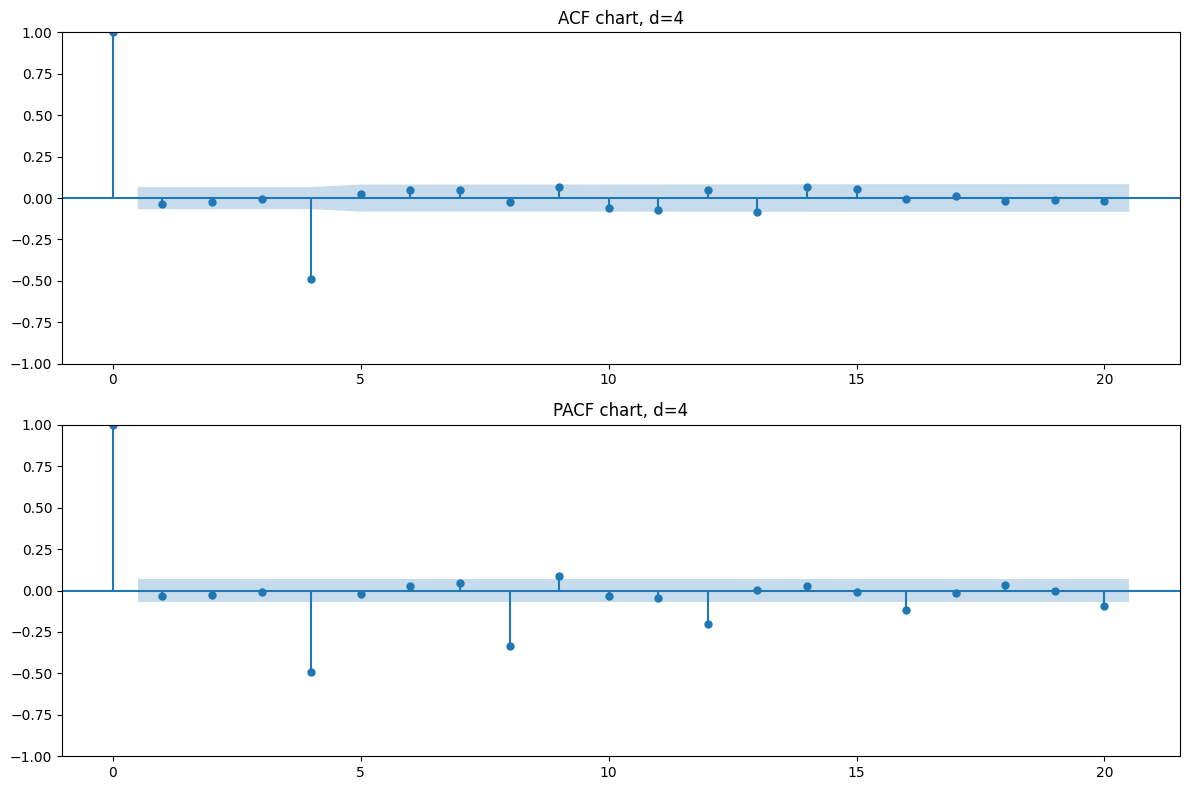

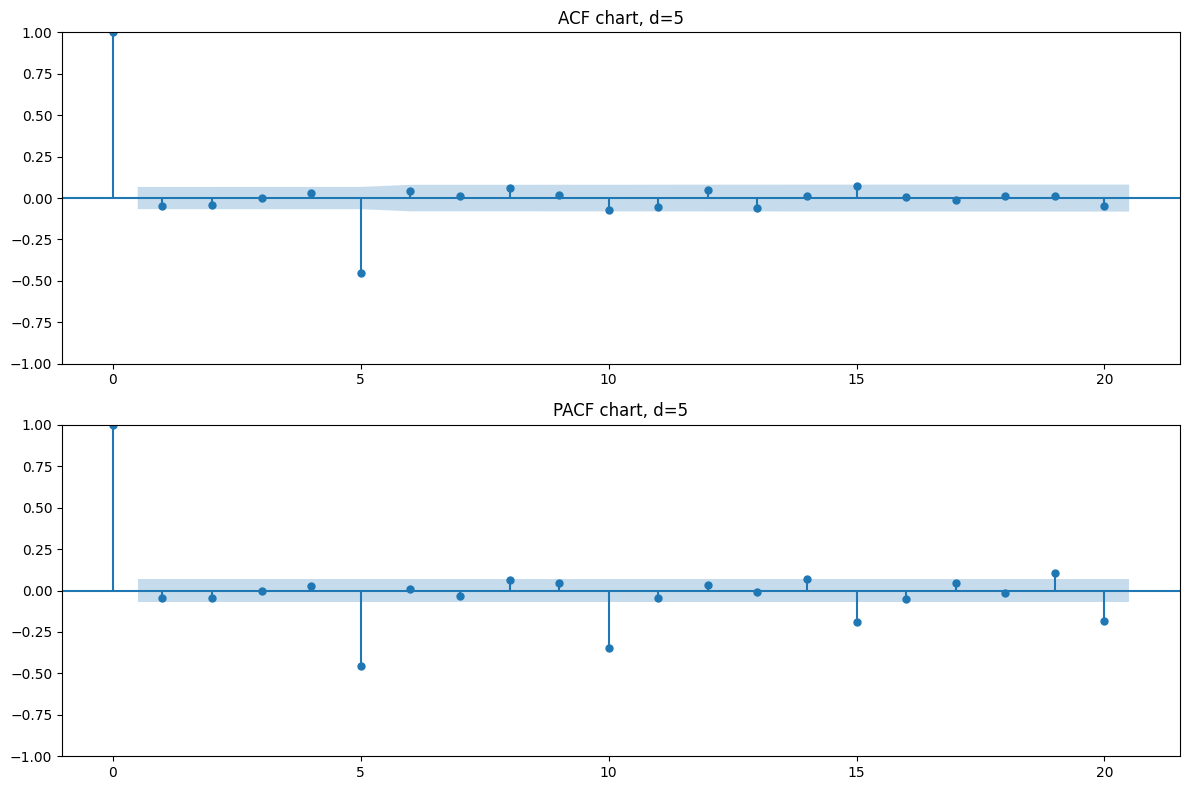

{'adf_test. d=0': (np.float64(-2.73875746764471),
  np.float64(0.06756828267057662),
  14,
  844,
  {'1%': np.float64(-3.4381216826257956),
   '5%': np.float64(-2.8649705364894635),
   '10%': np.float64(-2.568596692178972)},
  np.float64(10278.455241482856)),
 'adf_test. d=1': (np.float64(-13.040874103060567),
  np.float64(2.2425873805766977e-24),
  13,
  844,
  {'1%': np.float64(-3.4381216826257956),
   '5%': np.float64(-2.8649705364894635),
   '10%': np.float64(-2.568596692178972)},
  np.float64(10272.271037576491)),
 'adf_test. d=2': (np.float64(-11.658257704131792),
  np.float64(1.961491729867269e-21),
  15,
  841,
  {'1%': np.float64(-3.4381494909387555),
   '5%': np.float64(-2.864982795593248),
   '10%': np.float64(-2.568603222439172)},
  np.float64(10296.057683604675)),
 'adf_test. d=3': (np.float64(-10.559089304192101),
  np.float64(7.812555084910907e-19),
  17,
  838,
  {'1%': np.float64(-3.4381774989729816),
   '5%': np.float64(-2.8649951426291),
   '10%': np.float64(-2.56860

In [35]:
sqm_data = df["sqm"]

d_acf_pacf_charts(sqm_data, max_d = 5)

### Try differences of Price/Sqm

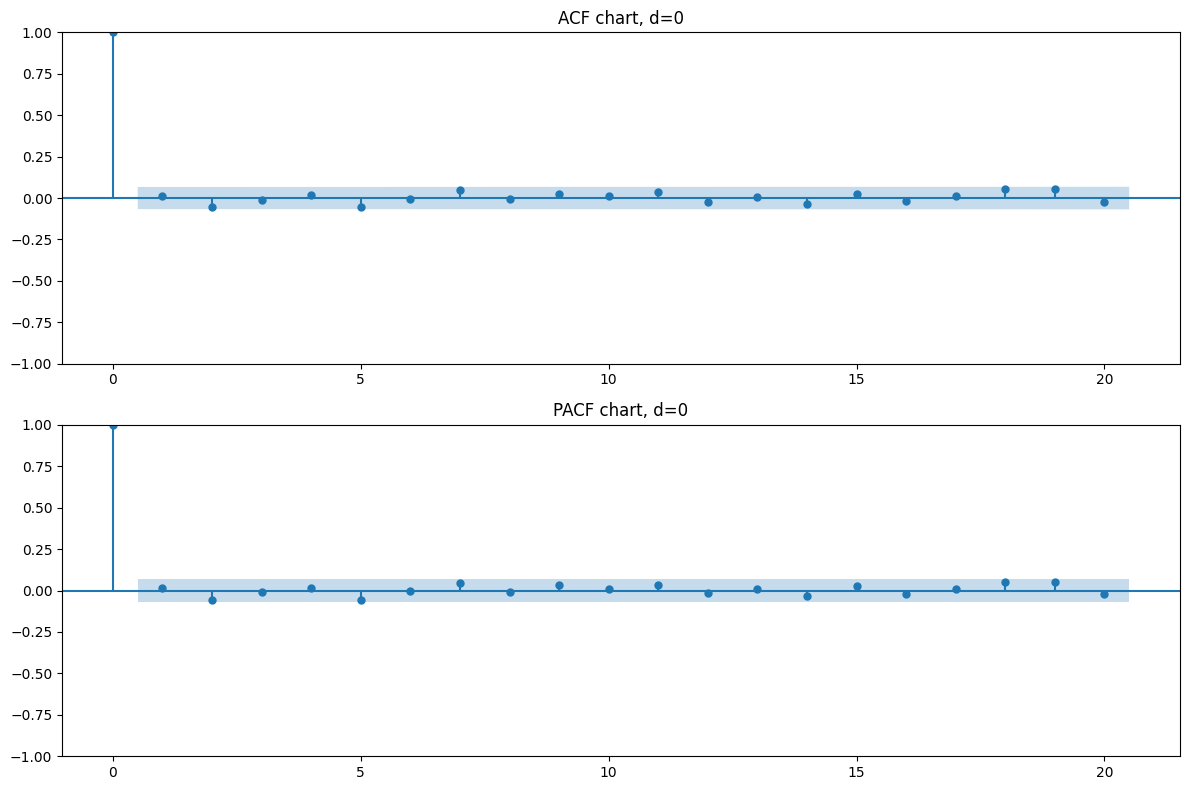

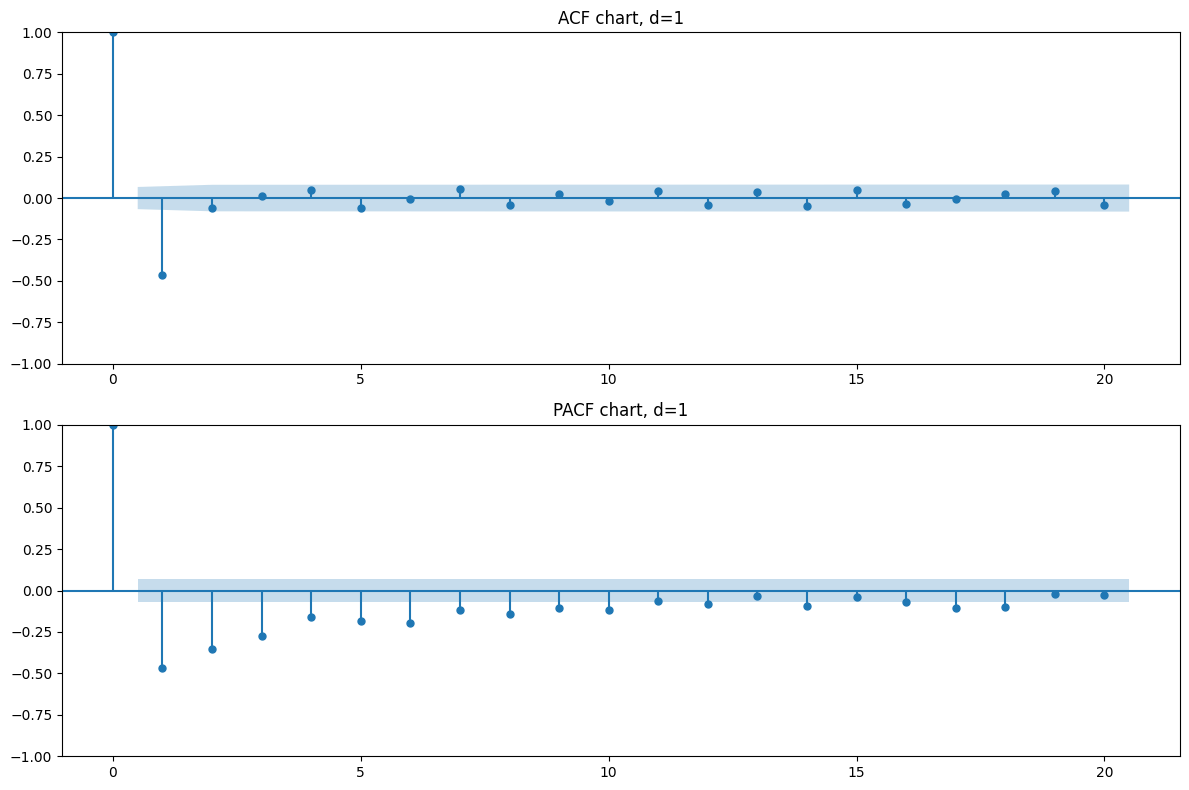

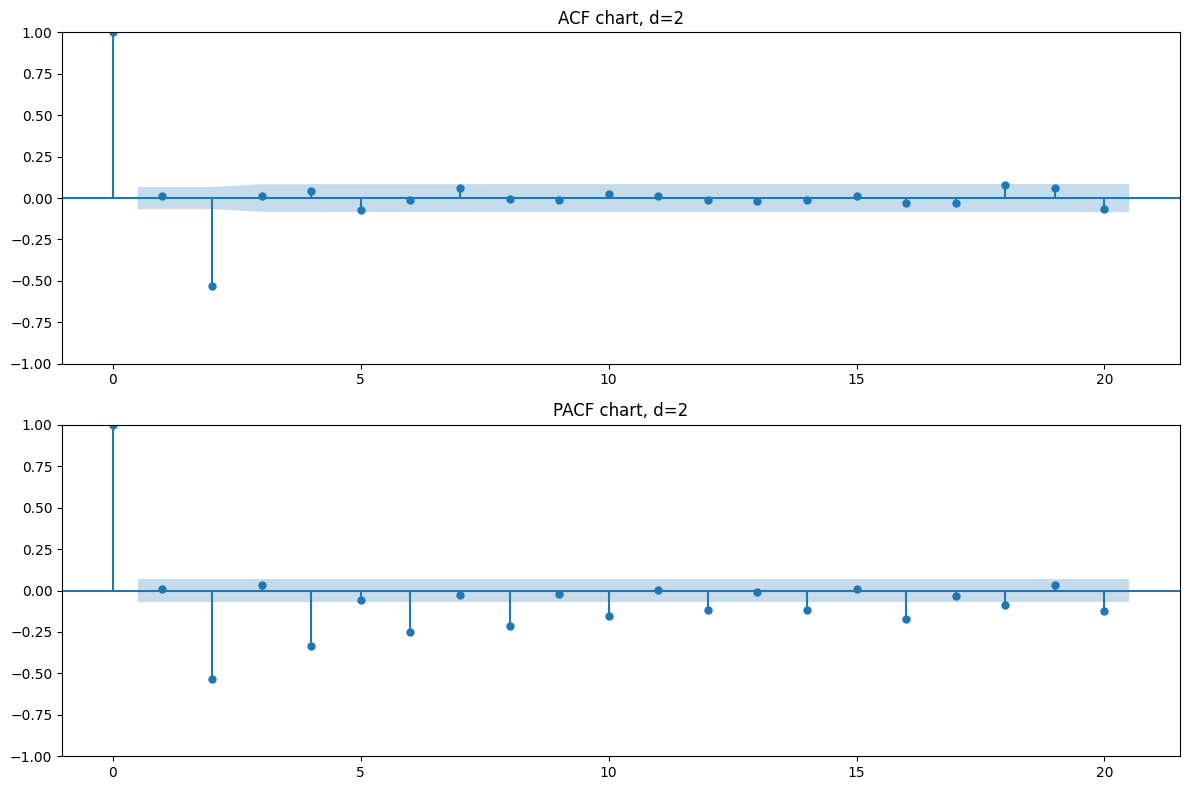

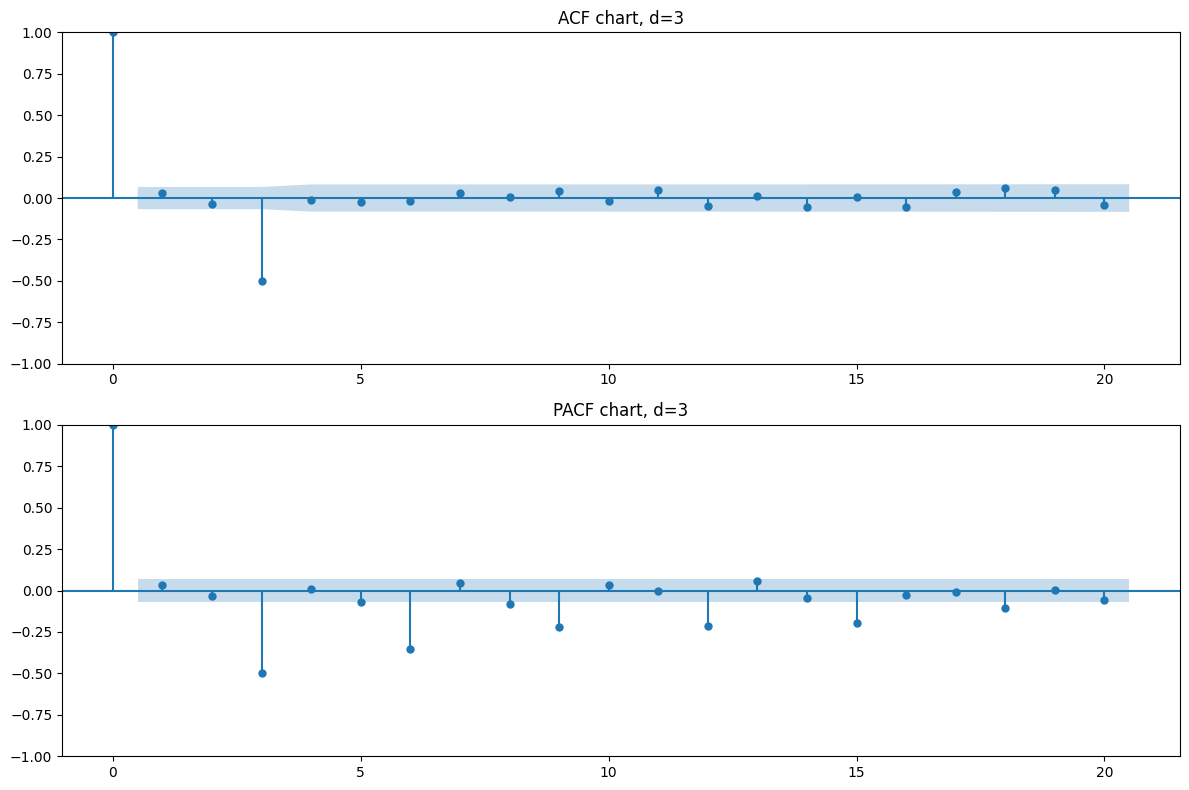

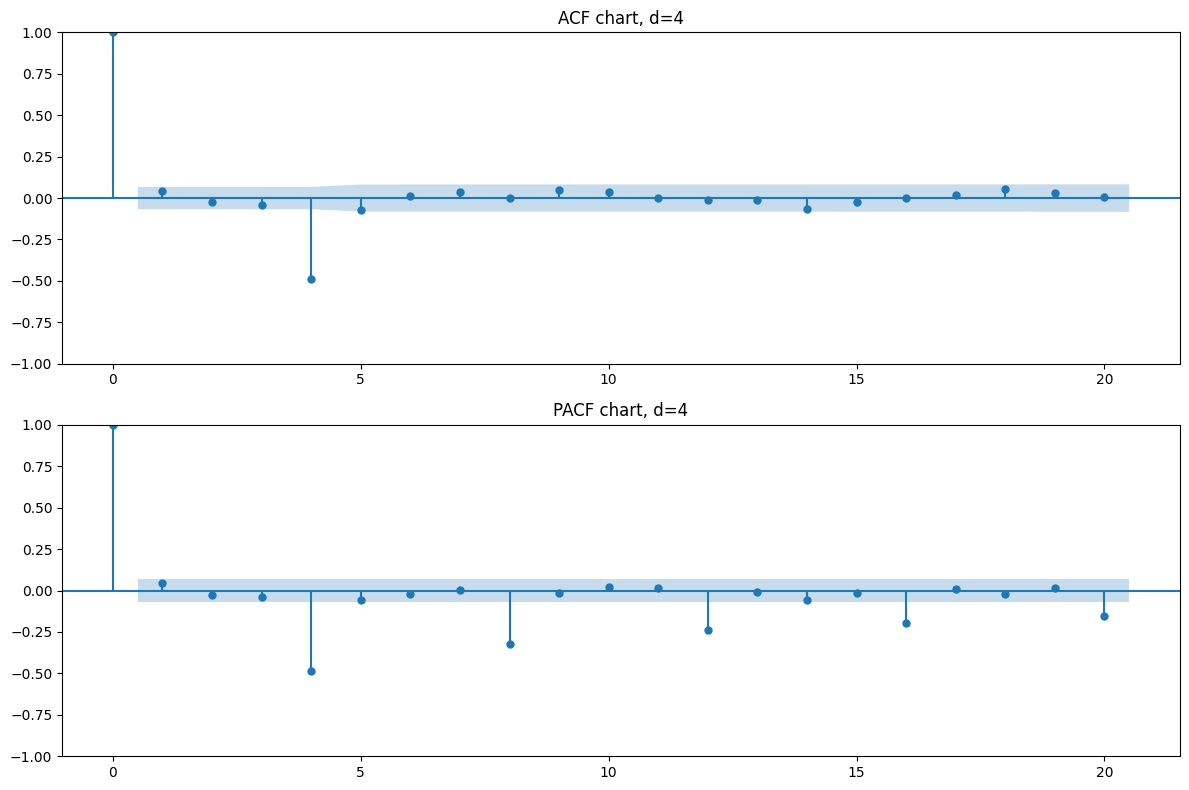

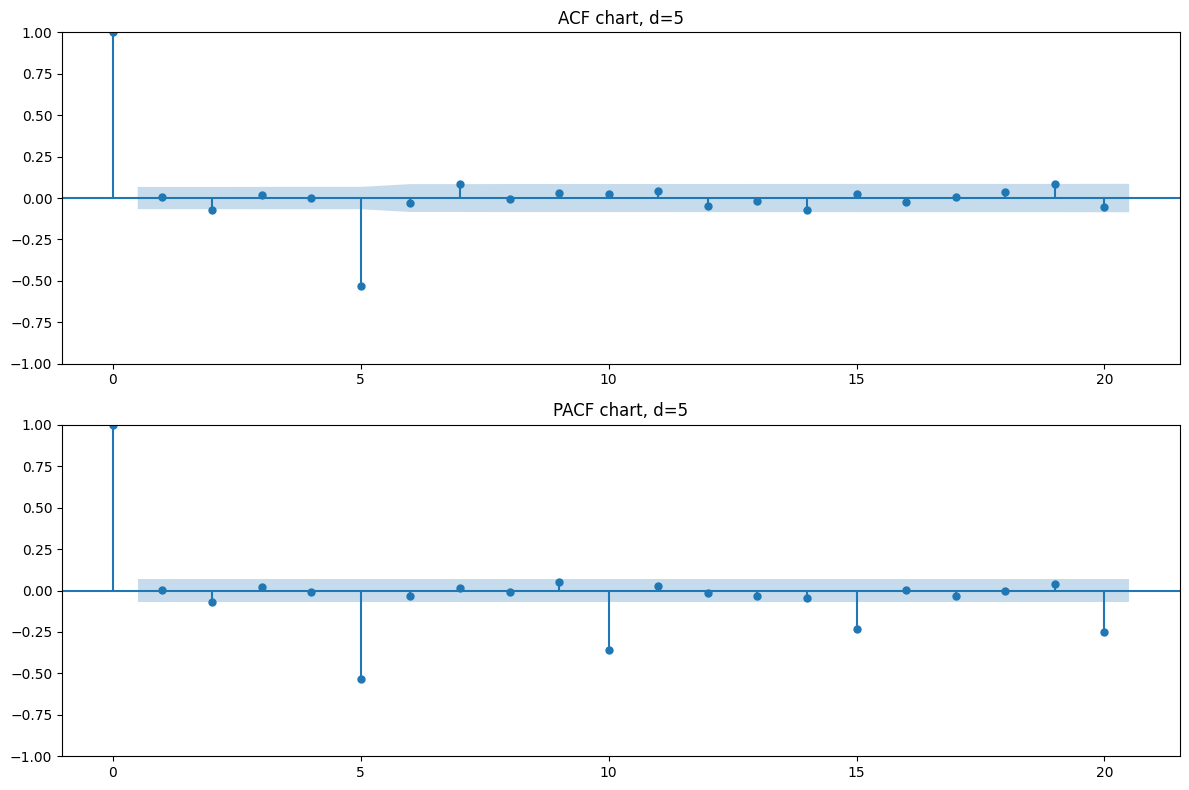

{'adf_test. d=0': (np.float64(-21.73198913663439),
  0.0,
  1,
  857,
  {'1%': np.float64(-3.438003436504483),
   '5%': np.float64(-2.864918407242872),
   '10%': np.float64(-2.5685689238190808)},
  np.float64(20928.732902591706)),
 'adf_test. d=1': (np.float64(-11.243395803917522),
  np.float64(1.783984903443907e-20),
  21,
  836,
  {'1%': np.float64(-3.4381962830171444),
   '5%': np.float64(-2.8650034233058093),
   '10%': np.float64(-2.568614210583549)},
  np.float64(20951.57944284165)),
 'adf_test. d=2': (np.float64(-11.611365051807113),
  np.float64(2.5085132343976205e-21),
  19,
  837,
  {'1%': np.float64(-3.4381868797392277),
   '5%': np.float64(-2.864999278011895),
   '10%': np.float64(-2.568612002429454)},
  np.float64(20966.060279466954)),
 'adf_test. d=3': (np.float64(-11.102859381135612),
  np.float64(3.826598452504176e-20),
  20,
  835,
  {'1%': np.float64(-3.4382057088878644),
   '5%': np.float64(-2.865007578546518),
   '10%': np.float64(-2.5686164240381513)},
  np.float64(

In [36]:
price_sqm_data = df["Price/Sqm"]

d_acf_pacf_charts(price_sqm_data, 5)

## Conclusion:
- This data isn't suitable for forecasting.
- The next step is to collect new data for forecasting